# Would kanye say this?
- kanye is a controvertial artist, this project helps you check if kanye would say a sentance or not, based on a machine learning model, that's trained on kanye tweets up to 2020

#### Load data and check it

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [84]:
kanye_df = pd.read_csv('tweets.csv') # Assuming the file name
kanye_df = kanye_df[['text']]
kanye_df['label'] = 1 

In [85]:
kanye_df.head(5)

,text,label
0,100 Best Places to Visit in USA - Valley of Fi...,1
1,Can we all agree that ye has a point\n\n#Kanye...,1
2,2022-12-19T10:00:04.5267368Z▶▶50% OFF! Get you...,1
3,#KanyeWest SUCK MY DİCK,1
4,50% OFF! Get yours NOW! \nhttps://t.co/gugpbKE...,1


need to remove the link and the hastags

In [86]:
import re

def clean_tweet(text):
    # 1. Remove URLs (links starting with http or https)
    text = re.sub(r'https?://\S+', '', text)
    
    # 2. Remove Hashtags (the # symbol and the word attached to it)
    text = re.sub(r'#\S+', '', text)
    
    # 3. Clean up extra spaces left behind
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [87]:
kanye_df['text'] = kanye_df['text'].apply(clean_tweet)

In [88]:
kanye_df.head(10)

,text,label
0,100 Best Places to Visit in USA - Valley of Fi...,1
1,Can we all agree that ye has a point,1
2,2022-12-19T10:00:04.5267368Z▶▶50% OFF! Get you...,1
3,SUCK MY DİCK,1
4,"50% OFF! Get yours NOW! December 19, 2022 at 0...",1
5,"Ye is the most recognised and original Jew, th...",1
6,Kanye did nothing wrong,1
7,"50% OFF! Get yours NOW! December 19, 2022 at 0...",1
8,Now playing Bobby Brown - Rock Wit'cha Listen ...,1
9,is one of top 3 favorite rappers just listen t...,1


now we need to romve promtion tweets

In [89]:
red_flags = ['OFF!', 'Get yours NOW', 'Limited offer', 'Buy now', 'Shop here', '50%', 'Discount']


is_ad = kanye_df['text'].str.contains('|'.join(red_flags), case=False, na=False)

kanye_df = kanye_df[~is_ad].copy()

kanye_df = kanye_df[kanye_df['text'].str.len() > 15]

In [90]:
kanye_df.head(10)

,text,label
0,100 Best Places to Visit in USA - Valley of Fi...,1
1,Can we all agree that ye has a point,1
5,"Ye is the most recognised and original Jew, th...",1
6,Kanye did nothing wrong,1
8,Now playing Bobby Brown - Rock Wit'cha Listen ...,1
9,is one of top 3 favorite rappers just listen t...,1
10,@elonmusk Shot yourself in foot Musk. Needed t...,1
11,100 Best Places to Visit in USA - San Antonio ...,1
12,The Sister Rita X Show Airs Daily from 4pm Pst...,1
13,Repent Ye: British studio helps ex-fans of get...,1


now let's add kanye tweets to the random qoutes

In [91]:
# Load a "Not Kanye" dataset (e.g., generic quotes)
other_df = pd.read_csv('quotes.csv') 
other_df = other_df[['quote']].rename(columns={'quote': 'text'})
other_df['label'] = 0  # 0 means "Not Kanye"

other_df = other_df.sample(n=len(kanye_df), random_state=42)

# Combine them into one big list
df = pd.concat([kanye_df, other_df]).sample(frac=1).reset_index(drop=True)

In [92]:
df.dropna(inplace=True)

now that we have done cleaning, let's check the data

In [93]:
df['label'].value_counts()

label
1    21980
0    21980
Name: count, dtype: int64

we have a big difference between out true label and our false label
so we won't aim for high accuracy instead high precission and recall

In [94]:
df.head(10)

,text,label
0,When I say to people: you should be in my shoe...,1
1,Everything burns if the flame is hot enough. T...,0
2,Another note to self,0
3,Whenever the Germans found the Canadian Corps ...,0
4,Y’all still think is crazy?! Can you imagine h...,1
5,The No. 1 most credible source of [online] rec...,0
6,Kanye West should be here! via @YouTube,1
7,I always wondered who played the gimp in Pulp ...,1
8,"i see no difference between ""past"" and ""paste""...",0
9,The first real day of spring is like the first...,0


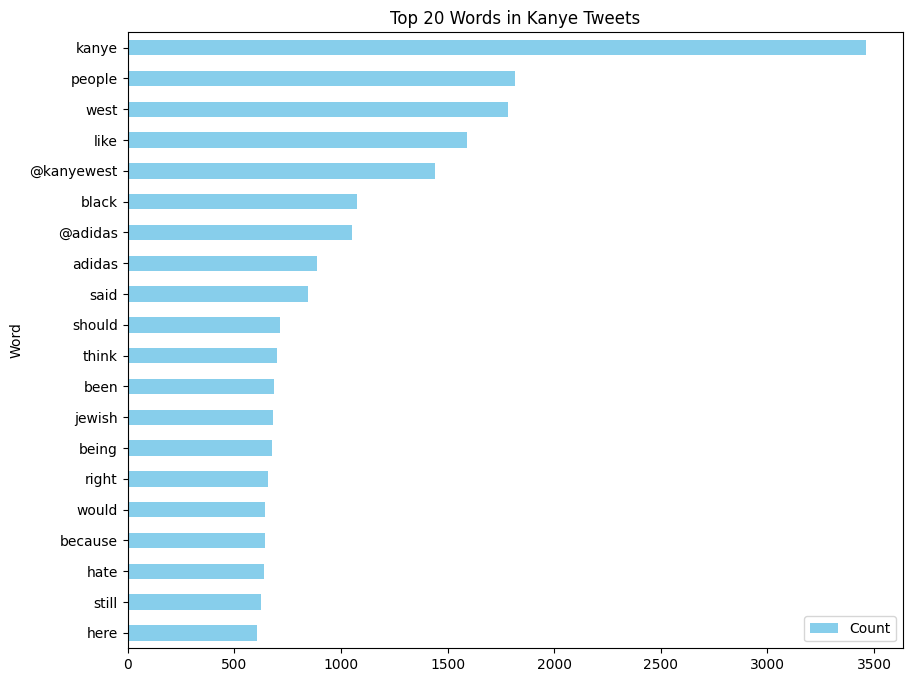

In [95]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

all_words = ' '.join(kanye_df['text']).lower().split()


stop_words = ['with','the', 'a', 'to', 'is', 'in',
               'and', 'i', 'of', 'for', 'it', 'my', 'on'
               ,'that','this','about','they','what','&amp;','have','just','your',
               'from','will','when','their','after','more','know','over']
filtered_words = [w for w in all_words if w not in stop_words and len(w) > 3]

# 3. Count the top 20 words
word_counts = Counter(filtered_words).most_common(20)
words_df = pd.DataFrame(word_counts, columns=['Word', 'Count'])

# 4. Plot it
words_df.plot.barh(x='Word', y='Count', color='skyblue', figsize=(10, 8))
plt.title('Top 20 Words in Kanye Tweets')
plt.gca().invert_yaxis() # Put the most frequent at the top
plt.show()

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# 1. Split data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2)

# 2. Create the Pipeline
# TfidfVectorizer: Converts text to a matrix of word importance
# MultinomialNB: A popular "Naive Bayes" model for text classification
model = Pipeline([
    ('vectorizer', TfidfVectorizer(stop_words='english')),
    ('classifier', MultinomialNB())
])

# 3. Train the model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [107]:
def guess_kanye(phrase):
    prediction = model.predict([phrase])
    print(prediction)
    if prediction[0] == 1:
        return "That sounds like Kanye!"
    else:
        return "Probably not Kanye."

# Example use:
print(guess_kanye("I love drake"))
print(guess_kanye("The weather is nice today for a walk"))

[1]
That sounds like Kanye!
[0]
Probably not Kanye.


In [98]:
model.score(X_test,y_test)

0.9225432211101001

In [110]:
y_preds = model.predict(X_test)

Text(0.5, 1.0, 'Confusion Matrix: Model Accuracy')

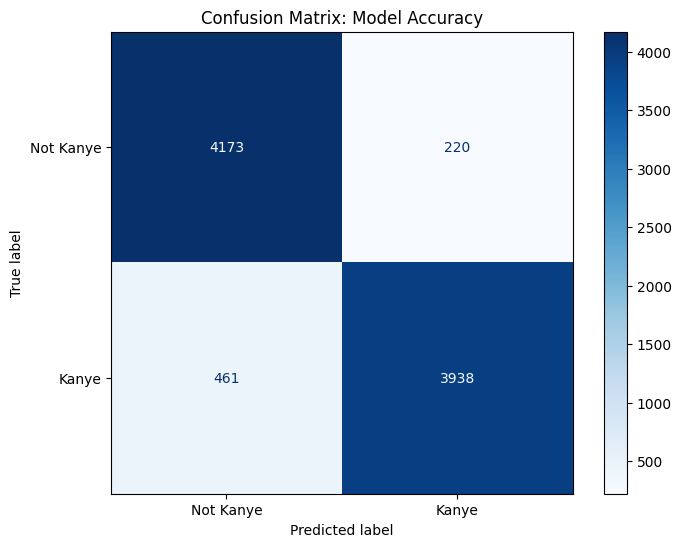

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score
cm = confusion_matrix(y_test, y_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Kanye', 'Kanye'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Model Accuracy')

In [108]:
import joblib
joblib.dump(model, 'kanye_model.pkl')

['kanye_model.pkl']